In [344]:
import pandas as pd
import numpy as np
import requests
from io import StringIO

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [345]:
from pandas_datareader import data as web

series = {
    "DGS2": "2Y Treasury Yield",
    "DGS10": "10Y Treasury Yield",
    "VIXCLS": "VIX",
    "DFF": "Federal Funds Rate"
}

start_date = "2021-01-01"
end_date = "2025-12-31"

market_data = pd.DataFrame()

for ticker, name in series.items():
    df = web.DataReader(
        ticker,
        "fred",
        start_date,
        end_date
    )
    df = df.rename(columns={ticker: name})
    
    if market_data.empty:
        market_data = df
    else:
        market_data = market_data.join(df, how="outer")

market_data.head()

,2Y Treasury Yield,10Y Treasury Yield,VIX,Federal Funds Rate
DATE,,,,
2021-01-01,NaN,NaN,NaN,0.09
2021-01-02,NaN,NaN,NaN,0.09
2021-01-03,NaN,NaN,NaN,0.09
2021-01-04,0.11,0.93,26.97,0.09
2021-01-05,0.13,0.96,25.34,0.09


In [346]:
market_data = market_data.ffill()

print("Missing values after filling:")
print(market_data.isna().sum())

market_data.head()

Missing values after filling:
2Y Treasury Yield     3
10Y Treasury Yield    3
VIX                   3
Federal Funds Rate    0
dtype: int64


,2Y Treasury Yield,10Y Treasury Yield,VIX,Federal Funds Rate
DATE,,,,
2021-01-01,NaN,NaN,NaN,0.09
2021-01-02,NaN,NaN,NaN,0.09
2021-01-03,NaN,NaN,NaN,0.09
2021-01-04,0.11,0.93,26.97,0.09
2021-01-05,0.13,0.96,25.34,0.09


In [347]:
market_data = market_data.dropna(
    subset=["2Y Treasury Yield", "10Y Treasury Yield", "VIX"],
    how="all"
)

print("Rows after removing non trading days:", len(market_data))
print("\nRemaining missing values:")
print(market_data.isna().sum())

Rows after removing non trading days: 1823

Remaining missing values:
2Y Treasury Yield     0
10Y Treasury Yield    0
VIX                   0
Federal Funds Rate    0
dtype: int64


In [348]:
market_data.to_csv(
    "../data/market_data_clean.csv",
    index=True
)

print("Saved:", len(market_data), "market observations")

Saved: 1823 market observations


In [349]:
market_data.index = pd.to_datetime(market_data.index)

fomc = pd.read_csv("../data/fomc_statements_clean.csv")
fomc["decision_date"] = pd.to_datetime(fomc["decision_date"])

fomc[["decision_date", "clean_text"]].head()

,decision_date,clean_text
0,2021-01-27,The Federal Reserve is committed to using its ...
1,2021-03-17,The Federal Reserve is committed to using its ...
2,2021-04-28,The Federal Reserve is committed to using its ...
3,2021-06-16,The Federal Reserve is committed to using its ...
4,2021-07-28,The Federal Reserve is committed to using its ...


In [350]:
fomc["decision_date"] = pd.to_datetime(fomc["decision_date"]).dt.normalize()

market_data.index = pd.to_datetime(market_data.index).normalize()

fomc_market = fomc.merge(
    market_data,
    left_on="decision_date",
    right_index=True,
    how="left"
)

fomc_market.head()

,decision_date,statement_date,clean_text,2Y Treasury Yield,10Y Treasury Yield,VIX,Federal Funds Rate
0,2021-01-27,2021-01-27,The Federal Reserve is committed to using its ...,0.12,1.04,37.21,0.08
1,2021-03-17,2021-03-17,The Federal Reserve is committed to using its ...,0.13,1.63,19.23,0.07
2,2021-04-28,2021-04-28,The Federal Reserve is committed to using its ...,0.17,1.63,17.28,0.07
3,2021-06-16,2021-06-16,The Federal Reserve is committed to using its ...,0.21,1.57,18.15,0.06
4,2021-07-28,2021-07-28,The Federal Reserve is committed to using its ...,0.20,1.26,18.31,0.10


In [351]:
hawkish_words = [
    "inflation", "inflationary", "elevated", "persistent",
    "tighten", "tightening", "restrictive", "higher",
    "raise", "raising", "increase", "increases",
    "strong", "firm", "overheating"
]

dovish_words = [
    "accommodative", "accommodation", "support",
    "supportive", "lower", "lowering", "reduce",
    "reduced", "easing", "ease", "patient",
    "weak", "weaker", "uncertainty", "downside"
]

def tone_score(text):
    text = text.lower()
    
    hawkish = sum(text.count(word) for word in hawkish_words)
    dovish = sum(text.count(word) for word in dovish_words)
    
    return hawkish - dovish

fomc_market["tone_score"] = fomc_market["clean_text"].apply(tone_score)

fomc_market[["decision_date", "tone_score"]].head(10)

,decision_date,tone_score
0,2021-01-27,2
1,2021-03-17,4
2,2021-04-28,3
3,2021-06-16,0
4,2021-07-28,3
5,2021-09-22,4
6,2021-11-03,5
7,2021-12-15,-1
8,2022-01-26,1
9,2022-03-16,13


In [352]:
fomc_market["2Y_next_day"] = fomc_market["2Y Treasury Yield"].shift(-1)
fomc_market["10Y_next_day"] = fomc_market["10Y Treasury Yield"].shift(-1)
fomc_market["VIX_next_day"] = fomc_market["VIX"].shift(-1)

fomc_market["2Y_reaction"] = (
    fomc_market["2Y_next_day"] - fomc_market["2Y Treasury Yield"]
)

fomc_market["10Y_reaction"] = (
    fomc_market["10Y_next_day"] - fomc_market["10Y Treasury Yield"]
)

fomc_market["VIX_reaction"] = (
    fomc_market["VIX_next_day"] - fomc_market["VIX"]
)

fomc_market[
    [
        "decision_date",
        "tone_score",
        "2Y_reaction",
        "10Y_reaction",
        "VIX_reaction"
    ]
].head(10)

,decision_date,tone_score,2Y_reaction,10Y_reaction,VIX_reaction
0,2021-01-27,2,0.01,0.59,-17.98
1,2021-03-17,4,0.04,0.00,-1.95
2,2021-04-28,3,0.04,-0.06,0.87
3,2021-06-16,0,-0.01,-0.31,0.16
4,2021-07-28,3,0.05,0.06,2.56
5,2021-09-22,4,0.22,0.28,-5.77
6,2021-11-03,5,0.22,-0.13,4.19
7,2021-12-15,-1,0.44,0.38,12.67
8,2022-01-26,1,0.82,0.34,-5.29
9,2022-03-16,13,0.71,0.74,-1.25


In [353]:
import statsmodels.api as sm

X = fomc_market[["tone_score"]]

X = sm.add_constant(X)

for y in ["2Y_reaction", "10Y_reaction", "VIX_reaction"]:
    model = sm.OLS(fomc_market[y], X).fit()

    print("\n" + "=" * 60)
    print("DEPENDENT VARIABLE:", y)
    print("=" * 60)
    print(model.summary())


DEPENDENT VARIABLE: 2Y_reaction
                            OLS Regression Results                            
Dep. Variable:            2Y_reaction   R-squared:                         nan
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Sun, 09 Aug 2026   Prob (F-statistic):                nan
Time:                        21:44:03   Log-Likelihood:                    nan
No. Observations:                  40   AIC:                               nan
Df Residuals:                      38   BIC:                               nan
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const             n

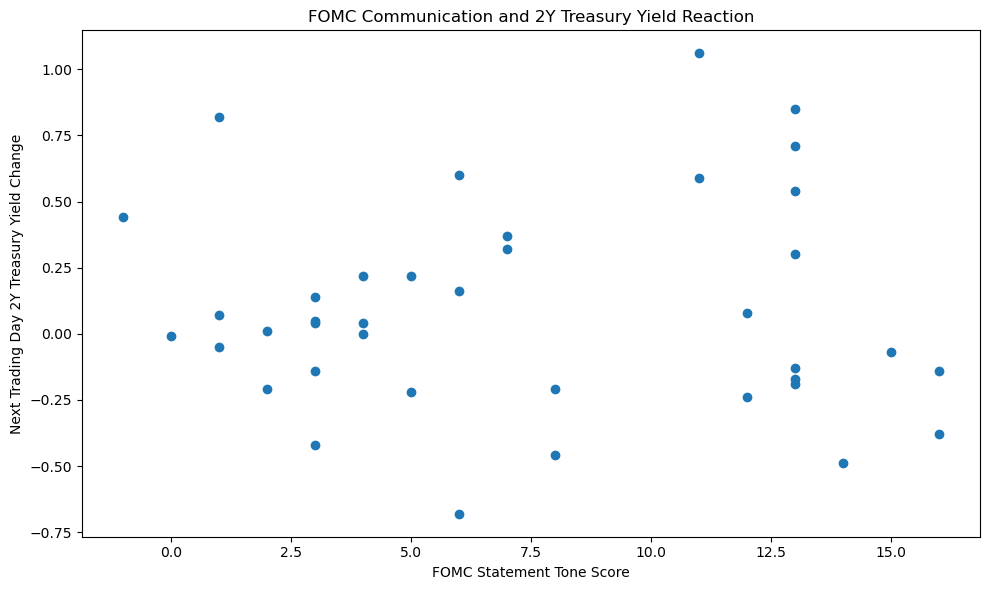

In [354]:
import matplotlib.pyplot as plt
import numpy as np

x = fomc_market["tone_score"]
y = fomc_market["2Y_reaction"]

slope, intercept = np.polyfit(x, y, 1)

plt.figure(figsize=(10, 6))

plt.scatter(x, y)

plt.plot(
    x,
    slope * x + intercept
)

plt.xlabel("FOMC Statement Tone Score")
plt.ylabel("Next Trading Day 2Y Treasury Yield Change")
plt.title("FOMC Communication and 2Y Treasury Yield Reaction")

plt.tight_layout()

plt.savefig(
    "../figures/fomc_tone_2y_reaction.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

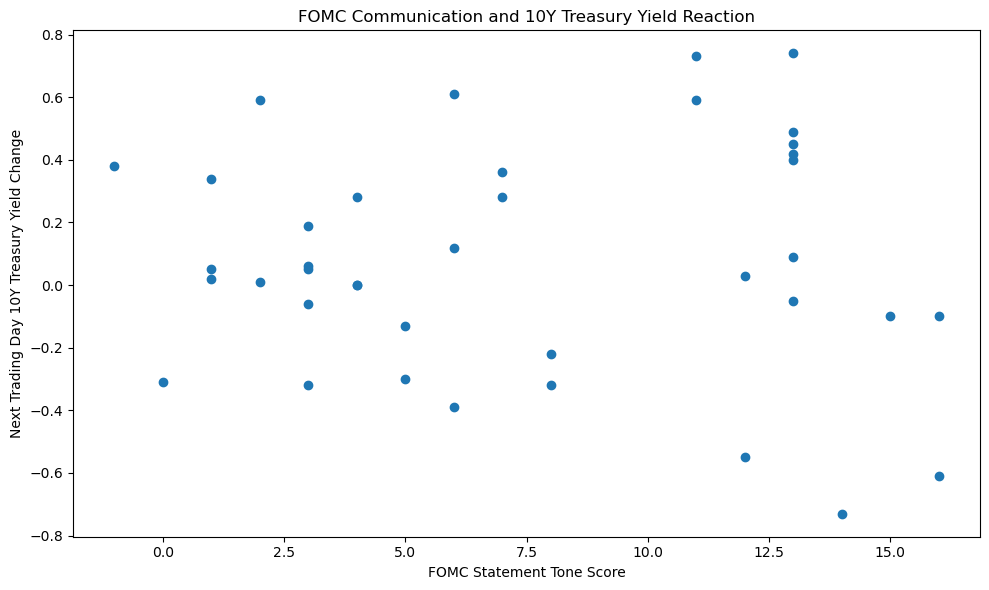

In [355]:
x = fomc_market["tone_score"]
y = fomc_market["10Y_reaction"]

slope, intercept = np.polyfit(x, y, 1)

plt.figure(figsize=(10, 6))

plt.scatter(x, y)

plt.plot(x, slope * x + intercept)

plt.xlabel("FOMC Statement Tone Score")
plt.ylabel("Next Trading Day 10Y Treasury Yield Change")
plt.title("FOMC Communication and 10Y Treasury Yield Reaction")

plt.tight_layout()

plt.savefig(
    "../figures/fomc_tone_10y_reaction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

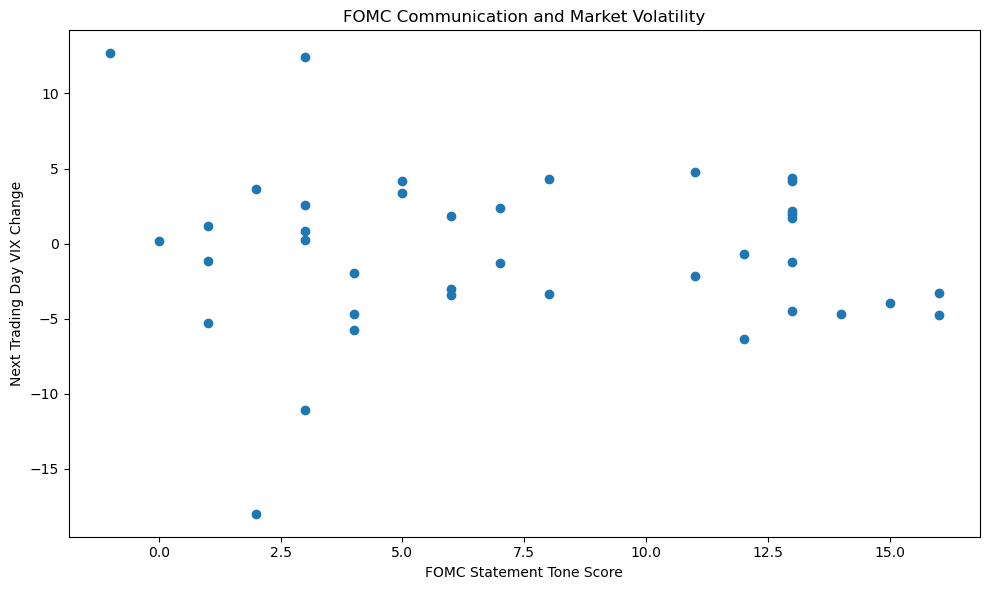

In [356]:
x = fomc_market["tone_score"]
y = fomc_market["VIX_reaction"]

slope, intercept = np.polyfit(x, y, 1)

plt.figure(figsize=(10, 6))

plt.scatter(x, y)

plt.plot(x, slope * x + intercept)

plt.xlabel("FOMC Statement Tone Score")
plt.ylabel("Next Trading Day VIX Change")
plt.title("FOMC Communication and Market Volatility")

plt.tight_layout()

plt.savefig(
    "../figures/fomc_tone_vix_reaction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [357]:
fomc_market["DFF_change"] = fomc_market["Federal Funds Rate"].diff()

results_control = []

for y in ["2Y_reaction", "10Y_reaction", "VIX_reaction"]:
    df = fomc_market[[y, "tone_score", "DFF_change"]].dropna()

    X = sm.add_constant(df[["tone_score", "DFF_change"]])
    model = sm.OLS(df[y], X).fit()

    results_control.append({
        "Outcome": y,
        "Tone_Coefficient": model.params["tone_score"],
        "Tone_P_value": model.pvalues["tone_score"],
        "DFF_Coefficient": model.params["DFF_change"],
        "DFF_P_value": model.pvalues["DFF_change"],
        "R_squared": model.rsquared,
        "Observations": int(model.nobs)
    })

control_results_df = pd.DataFrame(results_control)

control_results_df

,Outcome,Tone_Coefficient,Tone_P_value,DFF_Coefficient,DFF_P_value,R_squared,Observations
0,2Y_reaction,-0.014897,0.390037,0.380054,0.219508,0.042899,38
1,10Y_reaction,-0.003969,0.802930,0.117418,0.677879,0.005009,38
2,VIX_reaction,-0.146971,0.474903,-1.328529,0.715360,0.047279,38


In [358]:
hawkish_words = [
    "inflation", "inflationary", "elevated", "persistent",
    "upside", "tightening", "restrictive", "higher",
    "strong", "strength", "firm", "overheating",
    "raise", "raising", "increases", "increase"
]

dovish_words = [
    "accommodative", "accommodation", "support",
    "supportive", "lower", "lowering", "easing",
    "ease", "patient", "weak", "weaker",
    "downside", "uncertainty", "slowing",
    "reduced", "reduce"
]

def hawkishness_score(text):
    words = text.lower().split()
    
    hawkish = sum(
        word.strip(".,;:()[]\"'") in hawkish_words
        for word in words
    )
    
    dovish = sum(
        word.strip(".,;:()[]\"'") in dovish_words
        for word in words
    )
    
    total_words = len(words)
    
    return (hawkish - dovish) / total_words * 1000

fomc_market["hawkishness"] = fomc_market["clean_text"].apply(
    hawkishness_score
)

fomc_market[
    ["decision_date", "tone_score", "hawkishness"]
].head(10)

,decision_date,tone_score,hawkishness
0,2021-01-27,2,8.090615
1,2021-03-17,4,8.156607
2,2021-04-28,3,6.568144
3,2021-06-16,0,3.294893
4,2021-07-28,3,6.441224
5,2021-09-22,4,7.824726
6,2021-11-03,5,9.370817
7,2021-12-15,-1,1.529052
8,2022-01-26,1,5.328597
9,2022-03-16,13,24.948025


In [359]:
results_hawkish = []

for y in ["2Y_reaction", "10Y_reaction", "VIX_reaction"]:
    df = fomc_market[[y, "hawkishness", "DFF_change"]].dropna()

    X = sm.add_constant(df[["hawkishness", "DFF_change"]])
    model = sm.OLS(df[y], X).fit()

    results_hawkish.append({
        "Outcome": y,
        "Hawkishness_Coefficient": model.params["hawkishness"],
        "Hawkishness_P_value": model.pvalues["hawkishness"],
        "DFF_Coefficient": model.params["DFF_change"],
        "DFF_P_value": model.pvalues["DFF_change"],
        "R_squared": model.rsquared,
        "Observations": int(model.nobs)
    })

hawkish_results_df = pd.DataFrame(results_hawkish)

hawkish_results_df

,Outcome,Hawkishness_Coefficient,Hawkishness_P_value,DFF_Coefficient,DFF_P_value,R_squared,Observations
0,2Y_reaction,-0.008668,0.416544,0.364555,0.231689,0.040712,38
1,10Y_reaction,-0.000482,0.960731,0.080281,0.772969,0.003282,38
2,VIX_reaction,-0.060861,0.631287,-1.926833,0.592902,0.039510,38


In [360]:
event_data = []

for date in fomc_market["decision_date"]:
    before_dates = market_data.index[market_data.index < date]
    after_dates = market_data.index[market_data.index > date]

    if len(before_dates) > 0 and len(after_dates) > 0:
        before_date = before_dates[-1]
        after_date = after_dates[0]

        before = market_data.loc[before_date]
        after = market_data.loc[after_date]

        event_data.append({
            "decision_date": date,
            "2Y_event_reaction": after["2Y Treasury Yield"] - before["2Y Treasury Yield"],
            "10Y_event_reaction": after["10Y Treasury Yield"] - before["10Y Treasury Yield"],
            "VIX_event_reaction": after["VIX"] - before["VIX"]
        })

event_data = pd.DataFrame(event_data)

fomc_market = fomc_market.merge(
    event_data,
    on="decision_date",
    how="left"
)

fomc_market[
    [
        "decision_date",
        "hawkishness",
        "2Y_event_reaction",
        "10Y_event_reaction",
        "VIX_event_reaction"
    ]
].head(10)

,decision_date,hawkishness,2Y_event_reaction,10Y_event_reaction,VIX_event_reaction
0,2021-01-27,8.090615,0.01,0.02,7.19
1,2021-03-17,8.156607,0.01,0.09,1.79
2,2021-04-28,6.568144,-0.01,0.02,0.05
3,2021-06-16,3.294893,0.07,0.01,0.73
4,2021-07-28,6.441224,0.00,0.03,-1.66
5,2021-09-22,7.824726,0.05,0.08,-5.73
6,2021-11-03,9.370817,-0.05,-0.03,-0.59
7,2021-12-15,1.529052,-0.03,0.00,-1.32
8,2022-01-26,5.328597,0.16,0.03,-0.67
9,2022-03-16,24.948025,0.09,0.05,-4.16


In [361]:
event_results = []

for y in ["2Y_event_reaction", "10Y_event_reaction", "VIX_event_reaction"]:
    df = fomc_market[[y, "hawkishness", "DFF_change"]].dropna()

    X = sm.add_constant(df[["hawkishness", "DFF_change"]])
    model = sm.OLS(df[y], X).fit()

    event_results.append({
        "Outcome": y,
        "Hawkishness_Coefficient": model.params["hawkishness"],
        "Hawkishness_P_value": model.pvalues["hawkishness"],
        "DFF_Coefficient": model.params["DFF_change"],
        "DFF_P_value": model.pvalues["DFF_change"],
        "R_squared": model.rsquared,
        "Observations": int(model.nobs)
    })

event_results_df = pd.DataFrame(event_results)

event_results_df

,Outcome,Hawkishness_Coefficient,Hawkishness_P_value,DFF_Coefficient,DFF_P_value,R_squared,Observations
0,2Y_event_reaction,-0.007839,0.026590,0.100640,0.307506,0.137302,39
1,10Y_event_reaction,-0.006790,0.019698,0.091746,0.257694,0.148768,39
2,VIX_event_reaction,0.031551,0.589155,-0.533216,0.749952,0.008235,39


In [362]:
robust_results = []

for y in ["2Y_event_reaction", "10Y_event_reaction", "VIX_event_reaction"]:
    df = fomc_market[[y, "hawkishness", "DFF_change"]].dropna()

    X = sm.add_constant(df[["hawkishness", "DFF_change"]])

    model = sm.OLS(df[y], X).fit(cov_type="HC1")

    robust_results.append({
        "Outcome": y,
        "Hawkishness_Coefficient": model.params["hawkishness"],
        "Hawkishness_P_value": model.pvalues["hawkishness"],
        "DFF_Coefficient": model.params["DFF_change"],
        "DFF_P_value": model.pvalues["DFF_change"],
        "R_squared": model.rsquared,
        "Observations": int(model.nobs)
    })

robust_results_df = pd.DataFrame(robust_results)

robust_results_df

,Outcome,Hawkishness_Coefficient,Hawkishness_P_value,DFF_Coefficient,DFF_P_value,R_squared,Observations
0,2Y_event_reaction,-0.007839,0.030261,0.100640,0.383418,0.137302,39
1,10Y_event_reaction,-0.006790,0.018328,0.091746,0.317987,0.148768,39
2,VIX_event_reaction,0.031551,0.548593,-0.533216,0.744051,0.008235,39


In [363]:
policy_check = fomc_market[
    ["hawkishness", "DFF_change"]
].dropna()

X = sm.add_constant(policy_check["DFF_change"])

tone_model = sm.OLS(
    policy_check["hawkishness"],
    X
).fit()

fomc_market["unexpected_tone"] = np.nan

valid_idx = policy_check.index

fomc_market.loc[
    valid_idx,
    "unexpected_tone"
] = tone_model.resid

fomc_market[
    [
        "decision_date",
        "hawkishness",
        "DFF_change",
        "unexpected_tone"
    ]
].head(10)

,decision_date,hawkishness,DFF_change,unexpected_tone
0,2021-01-27,8.090615,NaN,NaN
1,2021-03-17,8.156607,-0.01,-5.191684
2,2021-04-28,6.568144,0.00,-6.966773
3,2021-06-16,3.294893,-0.01,-10.053398
4,2021-07-28,6.441224,0.04,-7.840202
5,2021-09-22,7.824726,-0.02,-5.336938
6,2021-11-03,9.370817,0.00,-4.164101
7,2021-12-15,1.529052,0.00,-12.005866
8,2022-01-26,5.328597,0.00,-8.206321
9,2022-03-16,24.948025,0.00,11.413107


In [364]:
unexpected_results = []

for y in [
    "2Y_event_reaction",
    "10Y_event_reaction",
    "VIX_event_reaction"
]:
    df = fomc_market[
        [y, "unexpected_tone"]
    ].dropna()

    X = sm.add_constant(df["unexpected_tone"])

    model = sm.OLS(
        df[y],
        X
    ).fit(cov_type="HC1")

    unexpected_results.append({
        "Outcome": y,
        "Unexpected_Tone_Coefficient": model.params["unexpected_tone"],
        "P_value": model.pvalues["unexpected_tone"],
        "R_squared": model.rsquared,
        "Observations": int(model.nobs)
    })

unexpected_results_df = pd.DataFrame(
    unexpected_results
)

unexpected_results_df

,Outcome,Unexpected_Tone_Coefficient,P_value,R_squared,Observations
0,2Y_event_reaction,-0.007839,0.029827,0.128131,39
1,10Y_event_reaction,-0.006790,0.016466,0.140883,39
2,VIX_event_reaction,0.031551,0.543662,0.008181,39


In [365]:
# Remove old two day reaction columns if they already exist
old_cols = [
    "2Y_2day_reaction",
    "10Y_2day_reaction",
    "VIX_2day_reaction"
]

fomc_market = fomc_market.drop(
    columns=[c for c in old_cols if c in fomc_market.columns]
)

# Merge the two day event reactions
fomc_market = fomc_market.merge(
    event_2day,
    on="decision_date",
    how="left"
)

# Check the resulting columns
fomc_market[
    [
        "decision_date",
        "hawkishness",
        "2Y_2day_reaction",
        "10Y_2day_reaction",
        "VIX_2day_reaction"
    ]
].head(10)

,decision_date,hawkishness,2Y_2day_reaction,10Y_2day_reaction,VIX_2day_reaction
0,2021-01-27,8.090615,0.00,0.06,10.07
1,2021-03-17,8.156607,0.01,0.12,1.16
2,2021-04-28,6.568144,-0.01,0.02,1.05
3,2021-06-16,3.294893,0.10,-0.06,3.68
4,2021-07-28,6.441224,-0.01,-0.01,-1.12
5,2021-09-22,7.824726,0.07,0.14,-6.61
6,2021-11-03,9.370817,-0.07,-0.11,0.45
7,2021-12-15,1.529052,-0.01,-0.03,-0.32
8,2022-01-26,5.328597,0.13,0.00,-3.50
9,2022-03-16,24.948025,0.12,-0.01,-5.96


In [366]:
two_day_results = []

for y in [
    "2Y_2day_reaction",
    "10Y_2day_reaction",
    "VIX_2day_reaction"
]:
    df = fomc_market[[y, "unexpected_tone"]].dropna()

    X = sm.add_constant(df["unexpected_tone"])

    model = sm.OLS(
        df[y],
        X
    ).fit(cov_type="HC1")

    two_day_results.append({
        "Outcome": y,
        "Unexpected_Tone_Coefficient": model.params["unexpected_tone"],
        "P_value": model.pvalues["unexpected_tone"],
        "R_squared": model.rsquared,
        "Observations": int(model.nobs)
    })

two_day_results_df = pd.DataFrame(two_day_results)

two_day_results_df

,Outcome,Unexpected_Tone_Coefficient,P_value,R_squared,Observations
0,2Y_2day_reaction,-0.006836,0.057348,0.081413,39
1,10Y_2day_reaction,-0.006362,0.042883,0.093486,39
2,VIX_2day_reaction,-0.054013,0.415207,0.018646,39


In [367]:
final_results = unexpected_results_df.copy()

final_results.to_csv(
    "../data/regression_results.csv",
    index=False
)

print("Regression results saved.")

Regression results saved.


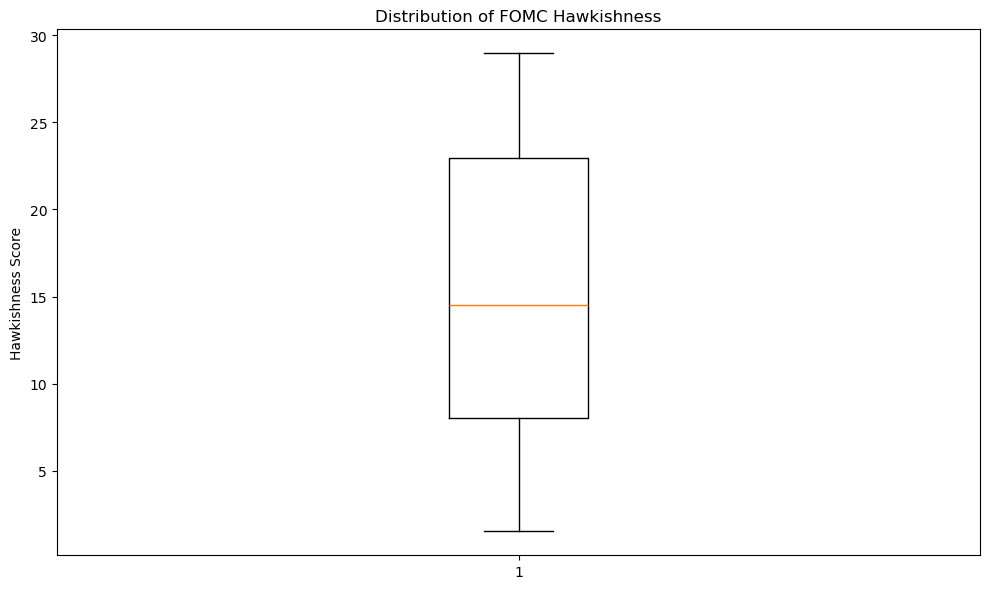

In [368]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.boxplot(
    fomc_market["hawkishness"].dropna()
)

plt.ylabel("Hawkishness Score")
plt.title("Distribution of FOMC Hawkishness")

plt.tight_layout()

plt.savefig(
    "../figures/hawkishness_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [369]:
df = fomc_market[
    ["2Y_event_reaction", "unexpected_tone"]
].dropna()

X = sm.add_constant(df["unexpected_tone"])
y = df["2Y_event_reaction"]

model = sm.OLS(y, X).fit()

influence = model.get_influence()

cooks_d = influence.cooks_distance[0]

influence_table = pd.DataFrame({
    "decision_date": fomc_market.loc[df.index, "decision_date"].values,
    "cooks_distance": cooks_d
})

print(influence_table.sort_values(
    "cooks_distance",
    ascending=False
).head(10))

   decision_date  cooks_distance
22    2023-12-13        0.206599
16    2023-03-22        0.203860
8     2022-03-16        0.200913
19    2023-07-26        0.092890
10    2022-06-15        0.063022
7     2022-01-26        0.043643
13    2022-11-02        0.040753
11    2022-07-27        0.040578
6     2021-12-15        0.033735
12    2022-09-21        0.030844


In [370]:
influential_dates = [
    "2023-12-13",
    "2023-03-22",
    "2022-03-16"
]

df = fomc_market[
    ["decision_date", "2Y_event_reaction", "unexpected_tone"]
].dropna()

robust_df = df[
    ~df["decision_date"].isin(
        pd.to_datetime(influential_dates)
    )
]

X = sm.add_constant(robust_df["unexpected_tone"])
y = robust_df["2Y_event_reaction"]

model_robust = sm.OLS(y, X).fit(cov_type="HC1")

print(model_robust.summary())

                            OLS Regression Results                            
Dep. Variable:      2Y_event_reaction   R-squared:                       0.082
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     4.781
Date:                Sun, 09 Aug 2026   Prob (F-statistic):             0.0357
Time:                        21:44:05   Log-Likelihood:                 29.208
No. Observations:                  36   AIC:                            -54.42
Df Residuals:                      34   BIC:                            -51.25
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.0279      0.019     

In [371]:
df = fomc_market[
    ["decision_date", "10Y_event_reaction", "unexpected_tone"]
].dropna()

robust_df_10y = df[
    ~df["decision_date"].isin(
        pd.to_datetime(influential_dates)
    )
]

X = sm.add_constant(robust_df_10y["unexpected_tone"])
y = robust_df_10y["10Y_event_reaction"]

model_robust_10y = sm.OLS(
    y,
    X
).fit(cov_type="HC1")

print("Coefficient:", model_robust_10y.params["unexpected_tone"])
print("P value:", model_robust_10y.pvalues["unexpected_tone"])
print("R squared:", model_robust_10y.rsquared)
print("Observations:", int(model_robust_10y.nobs))

Coefficient: -0.005676053727453039
P value: 0.043549262539072854
R squared: 0.09932550190469525
Observations: 36


In [372]:
df = fomc_market[
    ["decision_date", "2Y_2day_reaction", "unexpected_tone"]
].dropna()

X = sm.add_constant(df["unexpected_tone"])
y = df["2Y_2day_reaction"]

model_2day = sm.OLS(y, X).fit(cov_type="HC1")

influence = model_2day.get_influence()
cooks_d = influence.cooks_distance[0]

influence_2day = pd.DataFrame({
    "decision_date": df["decision_date"].values,
    "cooks_distance": cooks_d
})

print(
    influence_2day
    .sort_values("cooks_distance", ascending=False)
    .head(10)
)

   decision_date  cooks_distance
8     2022-03-16        0.193681
16    2023-03-22        0.165375
27    2024-07-31        0.114275
22    2023-12-13        0.088390
12    2022-09-21        0.067952
21    2023-11-01        0.046595
19    2023-07-26        0.040021
10    2022-06-15        0.038269
35    2025-07-30        0.027999
15    2023-02-01        0.026166


In [373]:
influential_dates_2day = [
    "2022-03-16",
    "2023-03-22",
    "2024-07-31"
]

df_2day = fomc_market[
    ["decision_date", "2Y_2day_reaction", "unexpected_tone"]
].dropna()

robust_df_2day = df_2day[
    ~df_2day["decision_date"].isin(
        pd.to_datetime(influential_dates_2day)
    )
]

X = sm.add_constant(robust_df_2day["unexpected_tone"])
y = robust_df_2day["2Y_2day_reaction"]

model_robust_2day = sm.OLS(
    y,
    X
).fit(cov_type="HC1")

print("Coefficient:", model_robust_2day.params["unexpected_tone"])
print("P value:", model_robust_2day.pvalues["unexpected_tone"])
print("R squared:", model_robust_2day.rsquared)
print("Observations:", int(model_robust_2day.nobs))

Coefficient: -0.006811811664751895
P value: 0.026387188296596493
R squared: 0.1195920300529153
Observations: 36


In [374]:
df_2day_10y = fomc_market[
    ["decision_date", "10Y_2day_reaction", "unexpected_tone"]
].dropna()

X = sm.add_constant(df_2day_10y["unexpected_tone"])
y = df_2day_10y["10Y_2day_reaction"]

model_2day_10y = sm.OLS(
    y,
    X
).fit(cov_type="HC1")

influence = model_2day_10y.get_influence()
cooks_d = influence.cooks_distance[0]

influence_2day_10y = pd.DataFrame({
    "decision_date": df_2day_10y["decision_date"].values,
    "cooks_distance": cooks_d
})

print(
    influence_2day_10y
    .sort_values("cooks_distance", ascending=False)
    .head(10)
)

   decision_date  cooks_distance
21    2023-11-01        0.179800
22    2023-12-13        0.138494
27    2024-07-31        0.083811
9     2022-05-04        0.071199
19    2023-07-26        0.068477
8     2022-03-16        0.041738
10    2022-06-15        0.038984
16    2023-03-22        0.036953
4     2021-09-22        0.030064
2     2021-06-16        0.028848


In [375]:
influential_dates_2day_10y = [
    "2023-11-01",
    "2023-12-13",
    "2024-07-31"
]

robust_df_2day_10y = df_2day_10y[
    ~df_2day_10y["decision_date"].isin(
        pd.to_datetime(influential_dates_2day_10y)
    )
]

X = sm.add_constant(
    robust_df_2day_10y["unexpected_tone"]
)

y = robust_df_2day_10y["10Y_2day_reaction"]

model_robust_2day_10y = sm.OLS(
    y,
    X
).fit(cov_type="HC1")

print(
    "Coefficient:",
    model_robust_2day_10y.params["unexpected_tone"]
)

print(
    "P value:",
    model_robust_2day_10y.pvalues["unexpected_tone"]
)

print(
    "R squared:",
    model_robust_2day_10y.rsquared
)

print(
    "Observations:",
    int(model_robust_2day_10y.nobs)
)

Coefficient: -0.0024946721269295466
P value: 0.33518815026234317
R squared: 0.020091231161975087
Observations: 36
